<a href="https://colab.research.google.com/github/mgkagori/ecommerce-edt/blob/Data-Samples/Business_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Forecasting the XLU Utilities Select Sector Index

#1. Introduction

This project builds and compares forecasting models for the Utilities Select Sector SPDR Fund (XLU), a capitalisation weighted index of major US utility companies. Utilities are defensive, dividend paying businesses held mainly for stable income, which is why the sectors value is expected to react strongly to interest rates, inflation and broad financial conditions. The task has two halves: forecast the next trading day's change in XLU, and identify which macro financial factors drive it.

Using daily data from 2020-2024, the target is modelled against six common predictors: CPI, the Federal Funds rate, crude oil and gold futures, 10-year Treasury futures and the US Dollar Index. The work matters to asset managers sizing and hedging utility exposure, corporate treasurers anticipating their cost of equity, and risk managers quantifying factor sensitivity.

The workflow runs from EDA and preprocessing to a naive baseline, then two models, ARIMA and a Random Forest, each judged on a rolling one step ahead back test i.e RMSE, MAE, MASE, directional accuracy. The Diebold-Mariano test checks whether differences are real, and the best model produces an out-of-sample forecast with uncertainty intervals


In [1]:
# Install skforecast
!pip install skforecast

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(palette="colorblind")
plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

#  Statistical tests / tools
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

#  Forecasting framework (skforecast)
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

from skforecast.recursive import (ForecasterRecursive,
                                  ForecasterEquivalentDate,
                                  ForecasterStats)
from skforecast.model_selection import TimeSeriesFold, grid_search_forecaster
from skforecast.model_selection._validation import (backtesting_forecaster,
                                                    backtesting_stats)
from skforecast.stats._arima import Arima

import shap

from skforecast.exceptions import IgnoredArgumentWarning, LongTrainingWarning
warnings.simplefilter("ignore", category=IgnoredArgumentWarning)
warnings.simplefilter("ignore", category=LongTrainingWarning)
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=RuntimeWarning)
warnings.simplefilter("ignore", category=UserWarning)

RANDOM_STATE = 7

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/bf/GRACE KAGORI-dataset.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Date,XLU,CPIAUCNS,FEDFUNDS,CL=F,GC=F,ZN=F,DX-Y.NYB
0,2020-01-02,26.4485,NaN,NaN,61.1800,"1,524.5000",128.6250,96.8500
1,2020-01-03,26.5024,NaN,NaN,63.0500,"1,549.2000",129.3906,96.8400
2,2020-01-06,26.5273,NaN,NaN,63.2700,"1,566.2000",129.2500,96.6700
3,2020-01-07,26.4900,NaN,NaN,62.7000,"1,571.8000",129.1562,96.9800
4,2020-01-08,26.4776,NaN,NaN,59.6100,"1,557.4000",128.7656,97.3000


In [3]:
raw = pd.read_csv("/content/drive/MyDrive/bf/GRACE KAGORI-dataset.csv", parse_dates=["Date"], date_format="%Y-%m-%d", index_col="Date").sort_index()

TARGET = "XLU"
EXOG = [c for c in raw.columns if c != TARGET]

# Human-readable labels for plots / tables
LABELS = {"XLU": "XLU (Utilities)", "CPIAUCNS": "CPI (Inflation)",
          "FEDFUNDS": "Fed Funds Rate", "CL=F": "Crude Oil",
          "GC=F": "Gold", "ZN=F": "10Y Treasury", "DX-Y.NYB": "US Dollar Index"}

raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   XLU       1258 non-null   float64
 1   CPIAUCNS  41 non-null     float64
 2   FEDFUNDS  41 non-null     float64
 3   CL=F      1258 non-null   float64
 4   GC=F      1258 non-null   float64
 5   ZN=F      1258 non-null   float64
 6   DX-Y.NYB  1258 non-null   float64
dtypes: float64(7)
memory usage: 78.6 KB


In [4]:
#Foward fill & back fill for CPI & Fed Funds, weekdays & holidays etc
data = raw.asfreq("B").ffill().bfill()
data.head()



,XLU,CPIAUCNS,FEDFUNDS,CL=F,GC=F,ZN=F,DX-Y.NYB
Date,,,,,,,
2020-01-02,26.4485,256.3890,0.0500,61.1800,"1,524.5000",128.6250,96.8500
2020-01-03,26.5024,256.3890,0.0500,63.0500,"1,549.2000",129.3906,96.8400
2020-01-06,26.5273,256.3890,0.0500,63.2700,"1,566.2000",129.2500,96.6700
2020-01-07,26.4900,256.3890,0.0500,62.7000,"1,571.8000",129.1562,96.9800
2020-01-08,26.4776,256.3890,0.0500,59.6100,"1,557.4000",128.7656,97.3000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1304 entries, 2020-01-02 to 2024-12-31
Freq: B
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   XLU       1304 non-null   float64
 1   CPIAUCNS  1304 non-null   float64
 2   FEDFUNDS  1304 non-null   float64
 3   CL=F      1304 non-null   float64
 4   GC=F      1304 non-null   float64
 5   ZN=F      1304 non-null   float64
 6   DX-Y.NYB  1304 non-null   float64
dtypes: float64(7)
memory usage: 81.5 KB


#2. EDA

##2.1 Train test split

In [6]:

#  explore the training set .
train_data, test_data = train_test_split(data, test_size=0.2, shuffle=False)
print(f"TRAIN : {train_data.index.min().date()} -> {train_data.index.max().date()}  ({len(train_data)} rows)")
print(f"TEST  : {test_data.index.min().date()} -> {test_data.index.max().date()}  ({len(test_data)} rows)")

TRAIN : 2020-01-02 -> 2024-01-01  (1043 rows)
TEST  : 2024-01-02 -> 2024-12-31  (261 rows)


In [7]:
train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
XLU,"1,043.0000",28.9937,2.7053,18.8094,27.1212,29.2936,30.9062,35.0919
CPIAUCNS,"1,043.0000",281.3931,18.5392,256.3890,260.4740,278.8020,297.2595,307.7890
FEDFUNDS,"1,043.0000",1.6912,2.1348,0.0500,0.0800,0.1000,4.1000,5.3300
CL=F,"1,043.0000",69.8155,22.2228,-37.6300,53.3550,72.9000,82.9500,123.7000
GC=F,"1,043.0000","1,828.7707",113.9200,"1,477.3000","1,758.1500","1,828.9000","1,919.1000","2,081.8999"
ZN=F,"1,043.0000",125.2534,11.0305,105.4219,114.0234,128.8906,134.7578,140.3281
DX-Y.NYB,"1,043.0000",98.9313,5.9241,89.4400,93.2800,98.9100,103.6200,114.1100


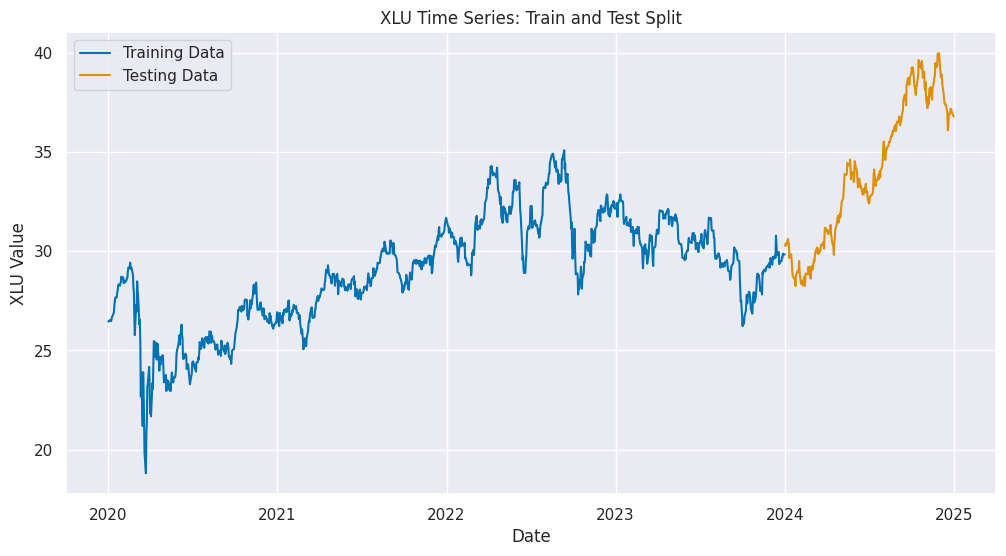

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(train_data['XLU'], label='Training Data')
plt.plot(test_data['XLU'], label='Testing Data')
plt.title('XLU Time Series: Train and Test Split')
plt.xlabel('Date')
plt.ylabel('XLU Value')
plt.legend()
plt.grid(True)
plt.show()

The target, XLU climbs into February 2020, then suffers the violent COVID-19 crash and it loses roughly a third of its value in about five weeks before recovering and trending sideways to down through the 2022–2023 rate hiking cycle. The series has a wandering level with no fixed mean.

##2.2 Predictors



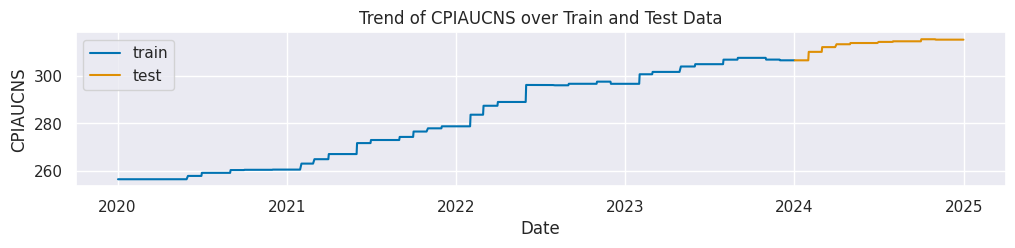

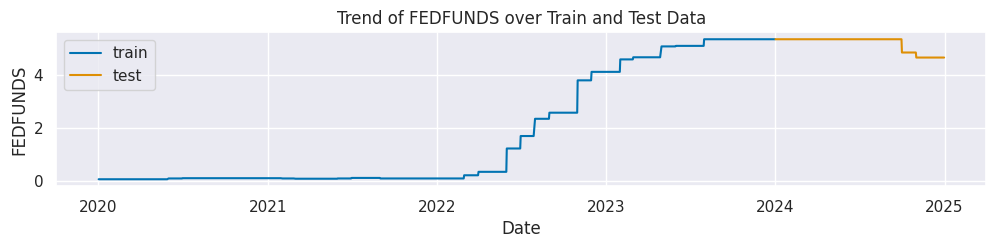

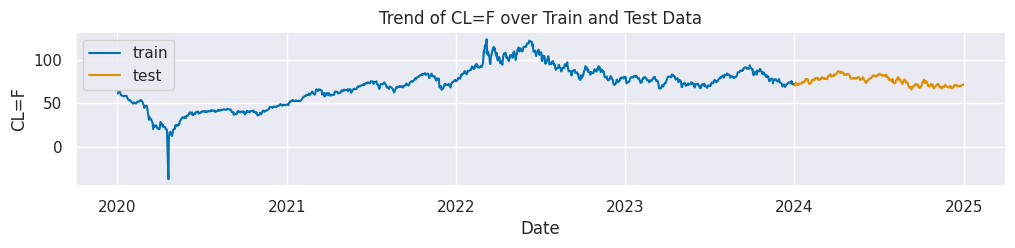

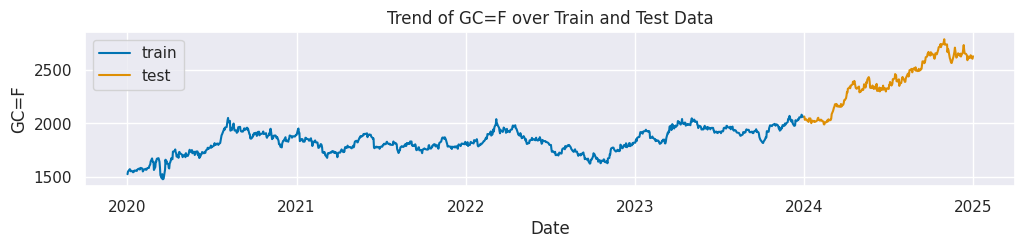

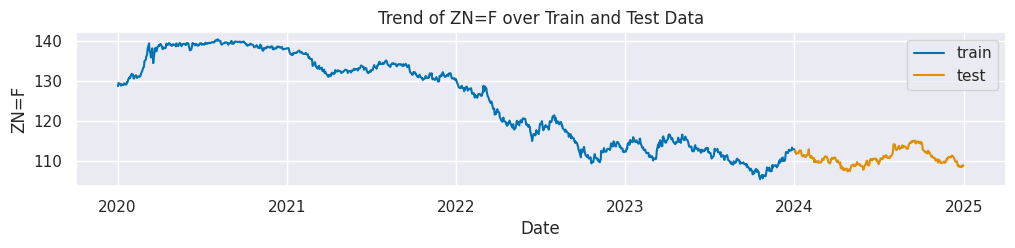

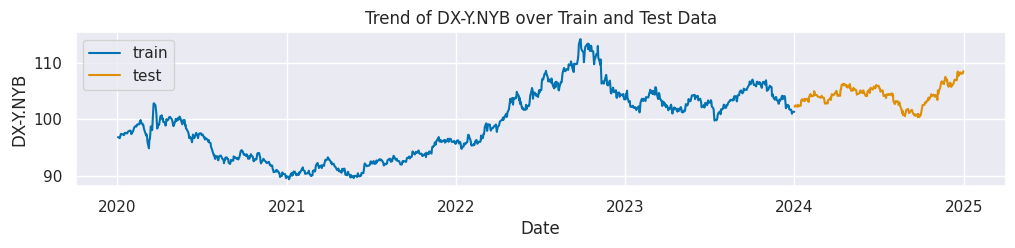

In [9]:
for x in EXOG:
    fig, ax = plt.subplots()
    fig.set_size_inches(12, 2)
    sns.lineplot(data=train_data, x=train_data.index, y=x, label='train')
    sns.lineplot(data=test_data, x=test_data.index, y=x, label='test')
    plt.title(f'Trend of {x} over Train and Test Data')
    plt.legend()
    plt.show()

The Fed Funds Rate and CPI plot have a monthly release frequency. The 10-year Treasury futures (ZN=F) fall steadily as the Fed raises rates in 2022 while the dollar (DXY) strengthens over the same period. Crude oil and gold show the commodity spikes of 2020 and 2022. Visually, the dollar's strength and Treasuries' weakness coincide with XLU's 2022 weakness, hinting at the rate sensitivity we expect.

##2.3 Trend and Seasonality

A decomposition separates the series into trend, a repeating seasonal component and a residual. We use a 21 day (one trading month) period to probe for any short calendar cycle, and also inspect the average return by weekday.

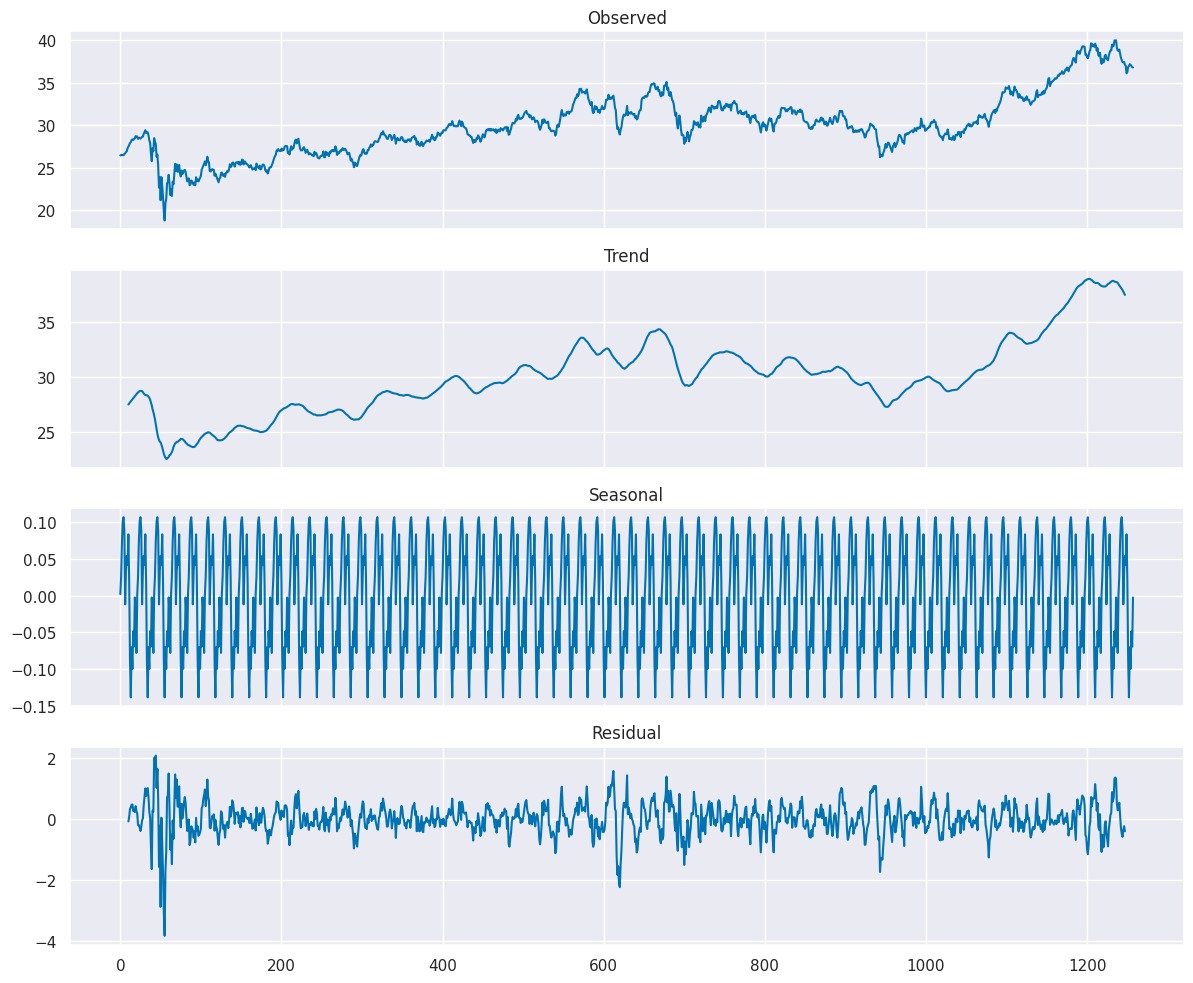

In [10]:
result = seasonal_decompose(df['XLU'], model='additive', period=21) # 21-day (one trading month)
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
result.observed.plot(ax=ax1, title='Observed')
result.trend.plot(ax=ax2, title='Trend')
result.seasonal.plot(ax=ax3, title='Seasonal')
result.resid.plot(ax=ax4, title='Residual')
plt.tight_layout()
plt.show()

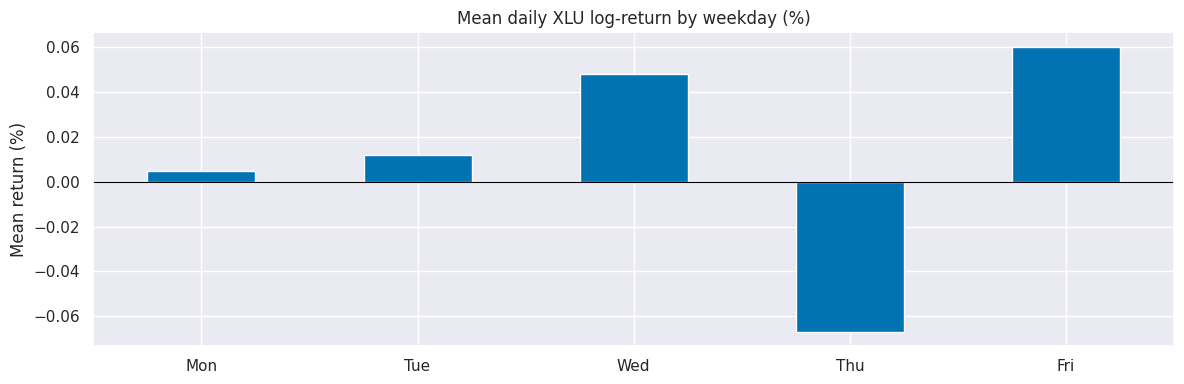

In [11]:
# Calendar seasonality check: mean daily log-return by weekday
weekday_ret = (np.log(train_data[TARGET]).diff()
               .groupby(train_data.index.dayofweek).mean() * 100)
weekday_ret.index = ["Mon", "Tue", "Wed", "Thu", "Fri"]
ax = weekday_ret.plot.bar(title="Mean daily XLU log-return by weekday (%)", rot=0)
ax.axhline(0, color="black", linewidth=0.8); ax.set_ylabel("Mean return (%)")
plt.tight_layout(); plt.show()

The decomposition is dominated by the trend component, whose amplitude (several dollars) dwarfs the seasonal component (a few cents that do not form a clean repeating shape).

 The weekday bar chart shows average returns within a couple of hundredths of a percent of zero, with no consistent pattern.

 XLU has a strong stochastic trend but no economically meaningful calendar seasonality which justifies using non seasonal models later and not engineering cyclical (day-of-week / month) features.

## 2.4 Returns, Volatility & Outliers

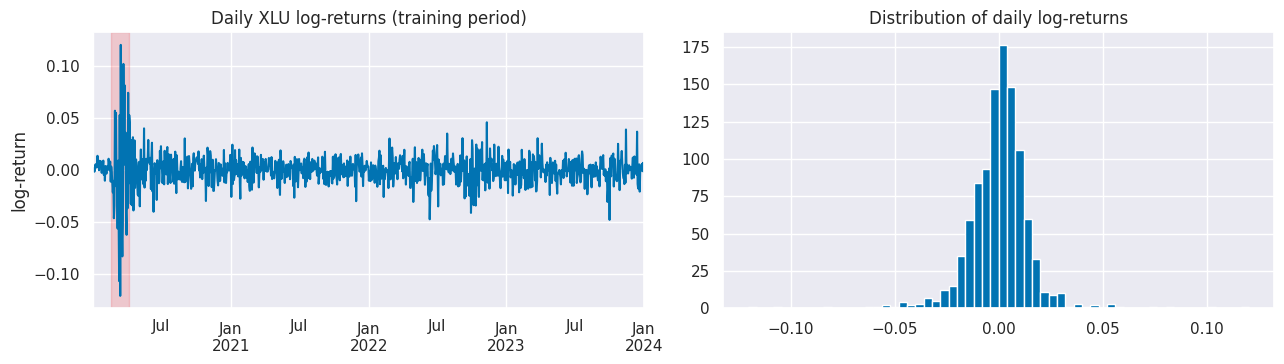

In [12]:
#Daily returns  with covid outlook
returns = np.log(train_data[TARGET]).diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
returns.plot(ax=axes[0], title="Daily XLU log-returns (training period)")
axes[0].axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-04-07"), color="red", alpha=0.15)
axes[0].set_xlabel(""); axes[0].set_ylabel("log-return")
returns.hist(bins=60, ax=axes[1]); axes[1].set_title("Distribution of daily log-returns")
plt.tight_layout(); plt.show()

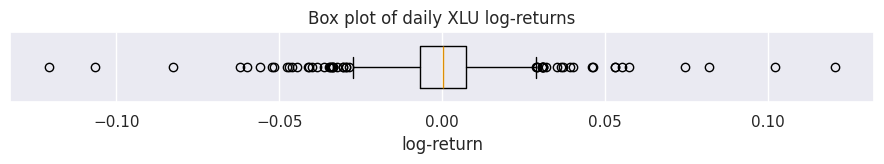

Return std = 0.0154. Days beyond +/-5 sigma (6 of 1042):
Date
2020-03-16   -12.0600
2020-03-12   -10.6400
2020-03-20    -8.2600
2020-03-26     8.1800
2020-03-24    10.2100
2020-03-17    12.0400


In [13]:
# Outliers: a boxplot, plus the most extreme days (|return| > 5 standard deviations)
returns = np.log(train_data[TARGET]).diff().dropna()

fig, ax = plt.subplots(figsize=(9, 1.8))
ax.boxplot(returns, orientation="horizontal", widths=0.6); ax.set_yticks([])
ax.set_title("Box plot of daily XLU log-returns"); ax.set_xlabel("log-return")
plt.tight_layout(); plt.show()

extreme = returns[returns.abs() > 5 * returns.std()].sort_values()
print(f"Return std = {returns.std():.4f}. Days beyond +/-5 sigma ({len(extreme)} of {len(returns)}):")
print((extreme * 100).round(2).to_string())

Three things stand out;

Volatility clustering, e.g. in the shaded COVID window exactly the conditional heteroscedasticity that motivates GARCH type models (noted in the future work section).


The return histogram is sharply peaked with heavier tails than a normal distribution: extreme days are more frequent than woud be predicted.


Outliers are real events, not errors. Every day beyond ±5σ falls in March 2020, genuine market dislocations, not data entry mistakes. We therefore do not delete them.

##2.5 What moves utilities? Correlation Analysis

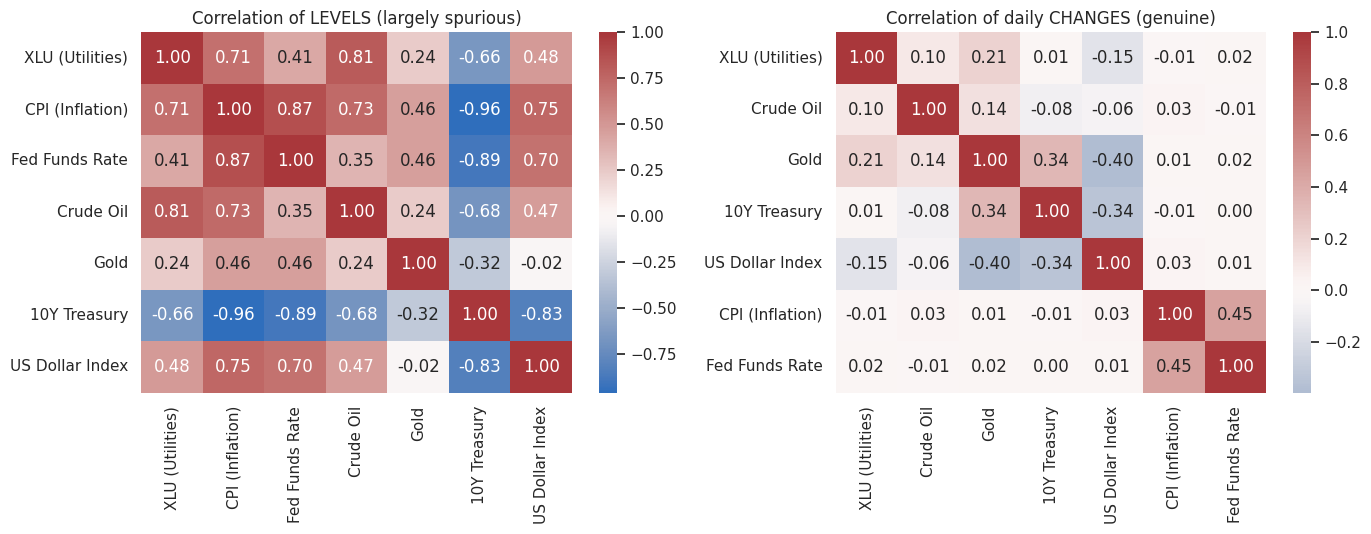

In [14]:

# Correlation of LEVELS
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(train_data.corr().rename(index=LABELS, columns=LABELS),
            annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0])
axes[0].set_title("Correlation of LEVELS (largely spurious)")

# Correlation of daily CHANGES (returns)
chg = np.log(train_data[[c for c in train_data.columns if c not in ("CPIAUCNS", "FEDFUNDS")]]).diff()
chg["CPIAUCNS"] = train_data["CPIAUCNS"].diff()
chg["FEDFUNDS"] = train_data["FEDFUNDS"].diff()
sns.heatmap(chg.dropna().corr().rename(index=LABELS, columns=LABELS),
            annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[1])
axes[1].set_title("Correlation of daily CHANGES (genuine)")
plt.tight_layout(); plt.show()

 The level correlations look large but are mostly spurious: any two trending series appear correlated simply because both drift over time. The changes/returns correlations reveal the genuine, much weaker relationshipsi.e.

US Dollar Index - negative: a stronger dollar accompanies tighter policy / higher real rates, which hurts rate sensitive utilities.

Gold - positive: both gold and utilities are defensive, real rate sensitive assets that do well when rates fall.

10-Year Treasury futures - mild positive: when bond prices rise (yields fall), the "bond proxy" utilities rise too.

CPI and Fed Funds - near zero daily correlation, because as monthly step series their daily change is zero on almost every day; their influence is monthly, not daily.



## 2.6 Stationarity Check for XLU (ADF Test) & Auto correlation

In [15]:
def adf_report(series, name):
    stat, pval, *_ = adfuller(series.dropna(), autolag="AIC")
    print(f"{name:18s} ADF stat = {stat:7.3f}   p-value = {pval:.4f}   -> "
          f"{'stationary' if pval < 0.05 else 'NON-stationary'}")

adf_report(train_data[TARGET], "XLU level")
adf_report(np.log(train_data[TARGET]).diff(), "XLU log-return")

XLU level          ADF stat =  -2.173   p-value = 0.2161   -> NON-stationary
XLU log-return     ADF stat =  -8.074   p-value = 0.0000   -> stationary


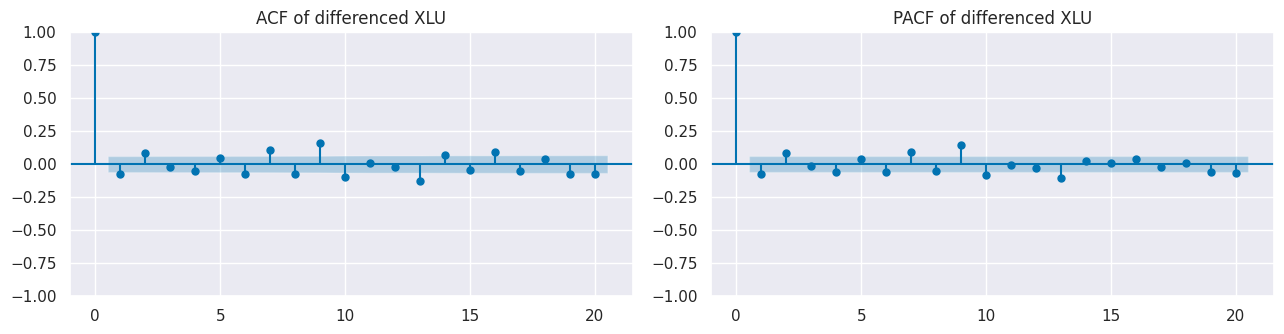

In [16]:
diff_xlu = train_data[TARGET].diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plot_acf(diff_xlu, lags=20, ax=axes[0]); axes[0].set_title("ACF of differenced XLU")
plot_pacf(diff_xlu, lags=20, ax=axes[1], method="ywm"); axes[1].set_title("PACF of differenced XLU")
plt.tight_layout(); plt.show()

The Augmented Dickey–Fuller test fails to reject the unit root null for the XLU level (p well above 0.05) but strongly rejects it for the log returns (p < 0.001): XLU is integrated of order one, I(1). After one difference the ACF/PACF spikes collapse into the confidence band with only minor short lag structure, confirming that one difference (d = 1) plus a low order ARIMA model is appropriate.

Therefore, models must operate on the differenced series, and the last observed value is an excellent naive forecast i.e. the benchmark our models must beat.

# 3. Data Preprocessing for Modeling

The cleaning required for exploration,i.e
- set a regular business day calendar (markets trade Mon-Fri)
- leak free forward fill, back fill,
- defining the EXOG & target variables
- and set a regular business-day calendar  

was applied in 2.1. This section covers the remaining, modelling specific preprocessing and records the decisions motivated by the EDA.

### COVID-19 structural break

The EDA identified March 2020 as a structural break with extreme, clustered returns. We retain the full history rather than deleting the episode or starting the sample after it. We instead acknowledge it as a limitation and revisit regime aware models in the future work section.


## 3.1 Prepare Data for Modelling


Lag is applied on every exogenous predictor by one trading day to forecast XLU at day t. The model may use factor values only up to day t-1. This makes the design strictly out of sample.

No scaling is applied as tree ensembles are scale invariant and ARIMA models a single series, so standardisation would add nothing here.

Differencing is handled inside each model, which keepsthe forecasts on the original price scale and lets a tree learn on a stationary target it can extrapolate.

Chronological split for modelling - no shuffling as time order must be preserved.

In [17]:
# Build the modelling frame from the cleaned data
df = data.copy()

# Lag every exogenous predictor by one trading day
df[EXOG] = df[EXOG].shift(1)
df = df.dropna()

train_set, test_set = train_test_split(df, test_size=0.2, random_state=7, shuffle=False)
print("train:", train_set.shape, " test:", test_set.shape)
print("train period:", train_set.index.min().date(), "->", train_set.index.max().date())
print("test period:", test_set.index.min().date(), "->", test_set.index.max().date())

train: (1042, 7)  test: (261, 7)
train period: 2020-01-03 -> 2024-01-01
test period: 2024-01-02 -> 2024-12-31


#4. Baseline Models

##4.1 Set up time Series Fold
Forecast one day ahead.


For an I(1) price series the natural benchmark is the last-value (naive / random-walk) forecast i.e. "tomorrow ≈ today". A mean forecast is added as a lower bound sanity check.

In [18]:
cv = TimeSeriesFold(
         steps=1, # =forecast horizon 1 day ahead
         initial_train_size=train_set.shape[0], # size of the initial training set
         refit=False, # if true, the forecaster is refitted at each fold
         fixed_train_size=False # fixed-size or expanding training data
     )



##4.2 Baseline

In [19]:
# Baseline 1: last-value (random walk)
last_value = ForecasterEquivalentDate(offset=1, n_offsets=1)
metrics = [root_mean_squared_error, mean_absolute_error]
res_lv, pred_lv = backtesting_forecaster(forecaster=last_value, y=df[TARGET], cv=cv,
                                         metric=metrics, verbose=False, show_progress=True)
res_lv.index = ["Last-Value"]

# Baseline 2: training mean
mean_fc = ForecasterRecursive(estimator=DummyRegressor(strategy="mean"), lags=1)
res_mean, pred_mean = backtesting_forecaster(forecaster=mean_fc, y=df[TARGET], cv=cv,
                                             metric=metrics, verbose=False, show_progress=True)
res_mean.index = ["Mean"]

pd.concat([res_lv, res_mean])

  0%|          | 0/261 [00:00<?, ?it/s]

  0%|          | 0/261 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
Last-Value,0.3278,0.2504
Mean,6.1393,5.0952


The last value forecast achieves an RMSE of roughly a third of a dollar because consecutive daily values barely change. The mean forecast is dramatically worse, because the test period sits well away from the training window average. This confirms the strong trend and that the last value, not the average, is the sensible benchmark. Beating the last value forecast is the bar our models must clear.

#5. Model Development and Evaluation

##5.1 Model 1 - ARIMA

ARIMA models a series through its own autoregressive and moving average structure after d differences. We follow the Box–Jenkins workflow where we use AutoARIMA to identify the order on the training data, then estimate a fixed model of that order inside the back test.

In [20]:
auto_arima = Arima(order=None, seasonal_order=(0, 0, 0),
                   start_p=0, start_q=0, max_p=4, max_q=4, max_d=2,
                   ic="aic", seasonal=False, test="adf", stepwise=False, trace=False)
auto_arima.fit(y=train_set[TARGET], suppress_warnings=True)
best_order = (auto_arima.order_spec_.p, auto_arima.order_spec_.d, auto_arima.order_spec_.q)
print("AutoARIMA selected order (p, d, q) =", best_order)

AutoARIMA selected order (p, d, q) = (4, 1, 1)


In [21]:
auto_arima.summary()

ARIMA Model Summary
Model     : AutoArima(4,1,1)
Method    : ARIMA(4,1,1)(0,0,0)[1]
Converged : True

Coefficients:
------------------------------------------------------------
  ar1            :    -0.8602  (SE:   0.1033, t:    -8.33)
  ar2            :     0.0348  (SE:   0.0416, t:     0.83)
  ar3            :     0.0467  (SE:   0.0417, t:     1.12)
  ar4            :    -0.0983  (SE:   0.0366, t:    -2.69)
  ma1            :     0.8099  (SE:   0.0955, t:     8.48)

Model fit statistics:
  sigma^2:             0.159644
  Log-likelihood:      -522.17
  AIC:                 1056.34
  BIC:                 1086.03

Residual statistics:
  Mean:                0.028736
  Std Dev:             0.912981
  MAE:                 0.305826
  RMSE:                0.912995

Time Series Summary Statistics:
Number of observations: 1042
  Mean:                 28.9961
  Std Dev:              2.7055
  Min:                  18.8094
  25%:                  27.1237
  Median:               29.2939
  75%:   

AutoARIMA selects an order with d = 1, confirming the single unit root, plus a small number of ARIMA terms, a parsimonious model close to a random walk with short memory corrections.

In [22]:
arima_fc = ForecasterStats(estimator=Arima(order=best_order, seasonal_order=(0, 0, 0)))
res_arima, pred_arima = backtesting_stats(forecaster=arima_fc, y=df[TARGET], cv=cv,
                                          metric=metrics, verbose=False, show_progress=False)
res_arima.index = ["ARIMA"]
res_arima

,root_mean_squared_error,mean_absolute_error
ARIMA,0.3368,0.2597


In [23]:
# Residual diagnostics: are the in sample residuals white noise? (Ljung-Box)
resid = pd.Series(np.asarray(auto_arima.get_residuals())).dropna()
print("Ljung-Box test on ARIMA residuals (lag 10):")
print(acorr_ljungbox(resid, lags=[10], return_df=True).to_string())

Ljung-Box test on ARIMA residuals (lag 10):
    lb_stat  lb_pvalue
10   0.9640     0.9999



A well-specified ARIMA leaves white noise residuals. A Ljung–Box p-value above 0.05 means we cannot reject "no remaining autocorrelation". The model has captured the available linear structure and the rest is essentially unpredictable noise, consistent with an efficient, near random walk price.

##5.2 Model 2 - Random Forest

The Random Forest is a non linear ensemble of decision trees. Unlike ARIMA it can exploit non linear interactions between the target's own past values (lags) and the exogenous factors (oil, gold, rates, the dollar, inflation).

 We tune the lags and key hyper parameters with a time series grid search on the training set, then evaluate on the test set. differentiation=1 makes the model forecast the first difference, removing the trend that trees cannot extrapolate.

In [24]:
rf_levels = ForecasterRecursive(
    estimator=RandomForestRegressor(n_estimators=200, max_depth=5,
                                    min_samples_leaf=5, random_state=RANDOM_STATE),
    lags=5)
res_rf_levels, _ = backtesting_forecaster(forecaster=rf_levels, y=df[TARGET], exog=df[EXOG],
                                          cv=cv, metric=metrics, verbose=False, show_progress=False)
res_rf_levels.index = ["Random Forest (raw level)"]
res_rf_levels

,root_mean_squared_error,mean_absolute_error
Random Forest (raw level),2.1334,1.4079


In [25]:
HORIZON = 1 # Define forecast horizon

# Hyper-parameter + lag search on the TRAINING set (internal 80/20 validation split).
forecaster_rf = ForecasterRecursive(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE), lags=5, differentiation=1)

lags_grid = [3, 5, 10]
param_grid = {"n_estimators": [200], "max_depth": [3, 5, 10], "min_samples_leaf": [1, 5, 10]}
cv_search = TimeSeriesFold(steps=HORIZON, initial_train_size=int(len(train_set) * 0.8),
                           refit=False, fixed_train_size=False, differentiation=1)

search = grid_search_forecaster(
    forecaster=forecaster_rf, y=train_set[TARGET], exog=train_set[EXOG],
    cv=cv_search, param_grid=param_grid, lags_grid=lags_grid,
    metric="mean_absolute_error", return_best=True, verbose=False, show_progress=True)
print("Best lags  :", search['lags'].iat[0])
print("Best params:", search['params'].iat[0])

lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/9 [00:00<?, ?it/s]

params grid:   0%|          | 0/9 [00:00<?, ?it/s]

params grid:   0%|          | 0/9 [00:00<?, ?it/s]

Best lags  : [ 1  2  3  4  5  6  7  8  9 10]
Best params: {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 200}


grid_search_forecaster evaluates every combination of lags and hyper parameters with rolling validation inside the training period and refits with the best configuration. Shallow trees are favoured, a sign that after differencing, there is little non-linear signal to exploit and the model must guard against over fitting noise.

In [26]:
# Evaluate the tuned Random Forest on the test set (back-test carries differentiation=1).
cv_rf = TimeSeriesFold(steps=HORIZON, initial_train_size=len(train_set),
                       refit=False, fixed_train_size=False, differentiation=1)
res_rf, pred_rf = backtesting_forecaster(forecaster=forecaster_rf, y=df[TARGET], exog=df[EXOG],
                                         cv=cv_rf, metric=metrics, verbose=False, show_progress=False)
res_rf.index = ["Random Forest"]
res_rf

,root_mean_squared_error,mean_absolute_error
Random Forest,0.3277,0.2504


## 5.3 Results comparison

RMSE and MAE alone do not tell the whole story. We add two measures:

MASE (Mean Absolute Scaled Error). MASE < 1 means the model beats the naive one step forecast, MASE > 1 means it is worse.

Directional accuracy which is the share of days on which the model gets the sign of the move right. For trading, direction often matters more than the exact level; 50% is the coin flip benchmark.

In [27]:
# In-sample naive MAE on the training target -> the MASE scaling factor
mase_scale = train_set[TARGET].diff().abs().mean()

def mase(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred)) / mase_scale

def directional_accuracy(y_true, y_pred, y_prev):
    actual_dir, pred_dir = np.sign(y_true - y_prev), np.sign(y_pred - y_prev)
    moved = actual_dir != 0                      # ignore unchanged days
    return float((actual_dir[moved] == pred_dir[moved]).mean())

# Align every model's predictions on the common test index
preds = {"Last-Value (naive)": pred_lv, "Mean": pred_mean,
         "ARIMA": pred_arima, "Random Forest": pred_rf}
common = pred_rf.index
for p in preds.values():
    common = common.intersection(p.index)
y_true = df.loc[common, TARGET].values
y_prev = df[TARGET].shift(1).loc[common].values

rows = []
for name, p in preds.items():
    yh = p.loc[common, "pred"].values
    rows.append([name, root_mean_squared_error(y_true, yh), mean_absolute_error(y_true, yh),
                 mase(y_true, yh), directional_accuracy(y_true, yh, y_prev)])
summary = (pd.DataFrame(rows, columns=["Model", "RMSE", "MAE", "MASE", "Directional Acc"])
           .set_index("Model").sort_values("RMSE"))
summary

,RMSE,MAE,MASE,Directional Acc
Model,,,,
Random Forest,0.3277,0.2504,0.8973,0.5502
Last-Value (naive),0.3278,0.2504,0.8973,0.0000
ARIMA,0.3368,0.2597,0.9305,0.4859
Mean,6.1393,5.0952,18.2588,0.4618


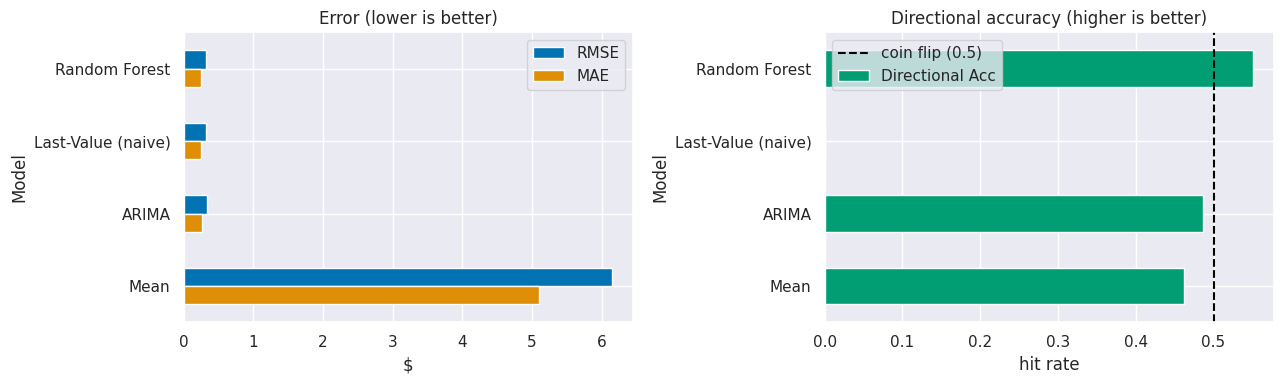

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
summary[["RMSE", "MAE"]].plot.barh(ax=axes[0]); axes[0].set_title("Error (lower is better)")
axes[0].set_xlabel("$"); axes[0].invert_yaxis()
summary["Directional Acc"].plot.barh(ax=axes[1], color=sns.color_palette("colorblind")[2])
axes[1].axvline(0.5, color="black", linestyle="--", label="coin flip (0.5)")
axes[1].set_title("Directional accuracy (higher is better)"); axes[1].set_xlabel("hit rate")
axes[1].invert_yaxis(); axes[1].legend()
plt.tight_layout(); plt.show()


No model beats the naive forecast on point accuracy. ARIMA and the Random Forest cluster at the last value baseline's RMSE; the Random Forest's MASE is identical to the naive forecast's ≈ 0.90, so it matches but does not beat the random walk.

MASE < 1 here only reflects a calmer test window. The naive forecast scores 0 by construction.

Directional accuracy hovers around 50%  essentially a coin flip with the Random Forest at highest at ≈ 0.55. None of the models reliably calls the direction of the next day's move.

The naive forecast predicts no change, so it scores 0 on directional accuracy by construction.


##5.4 Are the models statistically different? - Diebold-Mariano test

Equal error averages do not prove the models are equivalent. The Diebold-Mariano test formally compares two models' forecast error loss.

In [29]:
from scipy.stats import t as t_dist

def dm_test(actual, pred1, pred2, h=1, crit="MSE"):
    # Diebold-Mariano test with the Harvey-Leybourne-Newbold small-sample correction.
    # Returns (DM statistic, p-value). A negative statistic means pred1 has the smaller
    # loss (is more accurate) than pred2.
    actual, pred1, pred2 = map(np.asarray, (actual, pred1, pred2))
    e1, e2 = actual - pred1, actual - pred2
    d = e1**2 - e2**2 if crit == "MSE" else np.abs(e1) - np.abs(e2)
    n = len(d); dbar = d.mean()
    gamma = [np.sum((d[k:] - dbar) * (d[:n - k] - dbar)) / n for k in range(h)]
    var_d = (gamma[0] + 2 * sum(gamma[1:])) / n
    dm = dbar / np.sqrt(var_d)
    dm *= np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)   # HLN correction
    return dm, 2 * t_dist.cdf(-abs(dm), df=n - 1)

f = {name: preds[name].loc[common, "pred"].values
     for name in ["Last-Value (naive)", "ARIMA", "Random Forest"]}
for a, b in [("Random Forest", "Last-Value (naive)"), ("ARIMA", "Last-Value (naive)"),
             ("ARIMA", "Random Forest")]:
    stat, p = dm_test(y_true, f[a], f[b], h=HORIZON, crit="MSE")
    better = a if stat < 0 else b
    print(f"{a:>13s} vs {b:<20s} DM={stat:6.3f}  p={p:.3f}  -> "
          f"{'significant' if p < 0.05 else 'NOT significant'} (favours {better})")

Random Forest vs Last-Value (naive)   DM=-0.616  p=0.539  -> NOT significant (favours Random Forest)
        ARIMA vs Last-Value (naive)   DM= 2.775  p=0.006  -> significant (favours Last-Value (naive))
        ARIMA vs Random Forest        DM= 2.800  p=0.005  -> significant (favours Random Forest)


The Random Forest is statistically indistinguishable from the naive forecast at p ≈ 0.54. It matches but does not beat the benchmark.

ARIMA is significantly worse than both the naive forecast and the Random Forest at p ≈ 0.005.Tthe extra AR/MA terms, chosen to minimise insample AIC, very slightly hurt out of sample one step accuracy.

The practical conclusion is unchanged. Added model complexity delivers no accuracy gain over simply carrying yesterday's value forward.

##5.5 Which factors drive the sector? - SHAP

SHAP attributes each prediction to its features using a game theoretic, model agnostic decomposition. it gives, for every observation, a signed contribution telling us not just which factors matter but in which direction they push the forecast. We follow the skforecast explainability guide i.e. extract the exact training design matrix, then run SHAP's TreeExplainer on the forecaster's internal regressor.

In [30]:
X_train_rf, _ = forecaster_rf.create_train_X_y(y=train_set[TARGET], exog=train_set[EXOG])
explainer = shap.TreeExplainer(forecaster_rf.estimator)
shap_values = explainer.shap_values(X_train_rf)
print("SHAP values computed for design matrix:", X_train_rf.shape)

SHAP values computed for design matrix: (1031, 16)


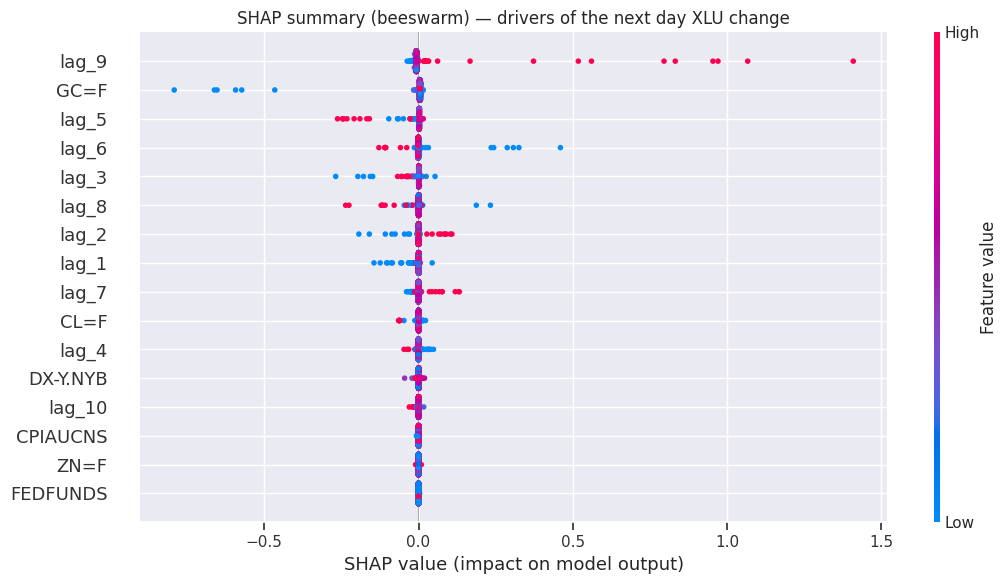

In [31]:
# Beeswarm summary: each dot is a day
shap.summary_plot(shap_values, X_train_rf, show=False, plot_size=(11, 6))
plt.title("SHAP summary (beeswarm) — drivers of the next day XLU change", fontsize=12)
plt.tight_layout(); plt.show()

In [32]:
# Sign of each exogenous factor's effect: correlation between its value and its SHAP value.
sign_rows = []
for feat in EXOG:
    j = list(X_train_rf.columns).index(feat)
    direction = np.corrcoef(X_train_rf[feat].values, shap_values[:, j])[0, 1]
    sign_rows.append([LABELS[feat], np.abs(shap_values[:, j]).mean(),
                      "raises XLU" if direction > 0 else "lowers XLU"])
pd.DataFrame(sign_rows, columns=["Factor", "Mean |SHAP|", "Higher value..."]
             ).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

,Factor,Mean |SHAP|,Higher value...
0,Gold,0.0076,raises XLU
1,Crude Oil,0.0012,lowers XLU
2,US Dollar Index,0.0007,lowers XLU
3,CPI (Inflation),0.0003,raises XLU
4,10Y Treasury,0.0002,raises XLU
5,Fed Funds Rate,0.0000,lowers XLU


The SHAP beeswarm confirms and enriches the impurity ranking. Gold is the dominant external driver, and its effect is positive high gold days sit on the positive SHAP side, i.e. a gold rally nudges the next day XLU forecast up.

The US dollar and crude oil act in the opposite direction a stronger dollar pushes the forecast down while the monthly macros (CPI, Fed Funds) contribute almost nothing day to day.

Crucially, the SHAP magnitudes are tiny relative to the spread contributed by the recent lags, which is the same message as before, the factors shape the small daily wobble, but the level is dominated by yesterday's price.

##5.6 Forecast visualisation and future outlook

The graph below shows the whole 2020–2025 history the training period the models learned from, and the test period they were evaluated on. Over the test period we overlay each model's honest one step ahead forecast and, for contrast, the naive forecast held flat from the train/test split.

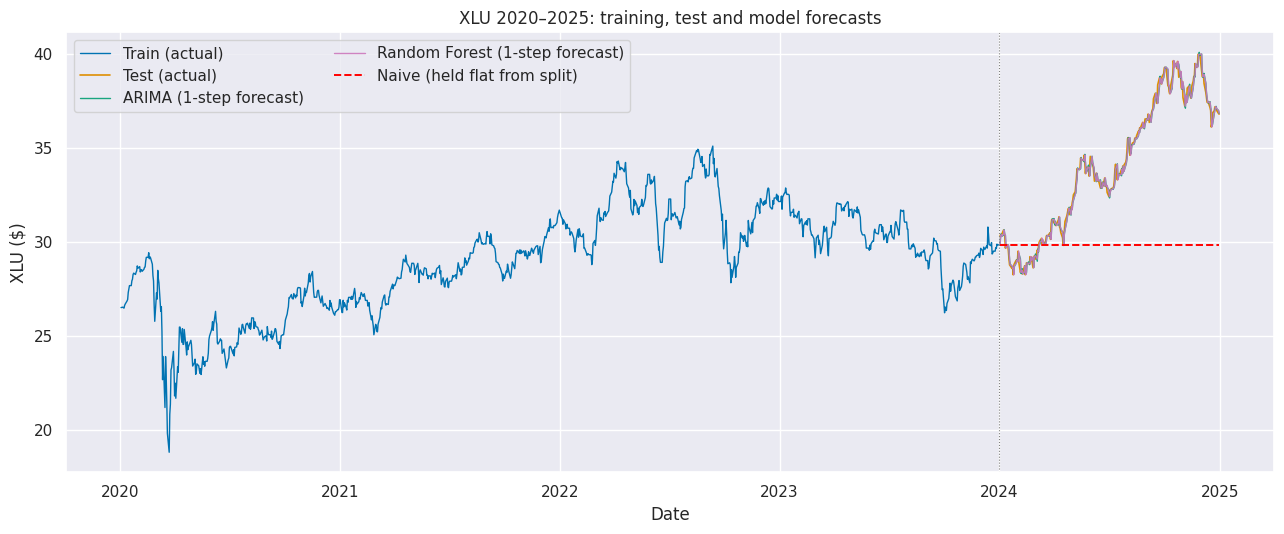

In [33]:
cb = sns.color_palette("colorblind")
split_value = train_set[TARGET].iloc[-1]          # last training value (the naive anchor)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(train_set.index, train_set[TARGET], color=cb[0], linewidth=1.0, label="Train (actual)")
ax.plot(test_set.index,  test_set[TARGET],  color=cb[1], linewidth=1.2, label="Test (actual)")
ax.plot(pred_arima.loc[common].index, pred_arima.loc[common, "pred"], color=cb[2],
        linewidth=1.0, alpha=0.9, label="ARIMA (1-step forecast)")
ax.plot(pred_rf.loc[common].index, pred_rf.loc[common, "pred"], color=cb[4],
        linewidth=1.0, alpha=0.9, label="Random Forest (1-step forecast)")
ax.plot(test_set.index, [split_value] * len(test_set), "--", color="red", linewidth=1.4,
        label="Naive (held flat from split)")
ax.axvline(train_set.index[-1], color="grey", linewidth=0.8, linestyle=":")
ax.set_title("XLU 2020–2025: training, test and model forecasts")
ax.set_ylabel("XLU ($)"); ax.set_xlabel("Date"); ax.legend(loc="upper left", ncol=2)
plt.tight_layout(); plt.show()

The one-step forecasts of ARIMA and the Random Forest sit almost exactly on top of the test line. The red dashed naive line held flat from the split shows the opposite extreme a forecast made once at the start of the test period and never updated is left far behind as the index drifts upward. The lesson is the practical difference between updating every day and forecasting far ahead.

##5.7 Genuine out of sample future forecast with uncertainty

Finally we refit ARIMA on the entire series and project 21 business days beyond the data with prediction intervals. The Random Forest is intentionally not projected multi step, with the predictors lagged by one day, forecasting several days out would require future values of oil, gold, rates and the dollar, so the free statistical model is the right tool for an unconditional future forecast. The chart is zoomed to the recent window so the 21 day interval cone is legible.

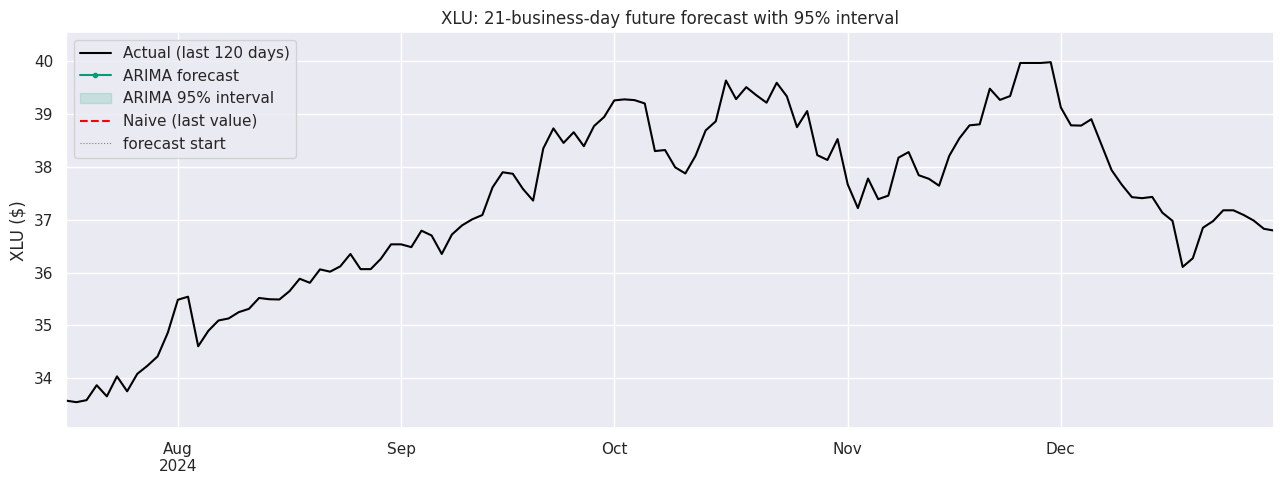

In [34]:
H_FUTURE = 21
future_idx = pd.date_range(df.index[-1], periods=H_FUTURE + 1, freq="B")[1:]
arima_full = Arima(order=best_order, seasonal_order=(0, 0, 0)); arima_full.fit(y=df[TARGET])
pi_arima = arima_full.predict_interval(steps=H_FUTURE).set_index(future_idx)
last_obs = df[TARGET].iloc[-1]

# Anchor the forecast to the last actual point so the curve is continuous.
hist = df[TARGET].iloc[-120:]
link_idx = hist.index[-1:].append(future_idx)
def linked(v): return np.concatenate([[last_obs], np.asarray(v)])

fig, ax = plt.subplots(figsize=(13, 5))
hist.plot(ax=ax, color="black", linewidth=1.5, label="Actual (last 120 days)")
ax.plot(link_idx, linked(pi_arima["mean"]), color=cb[2], marker=".", label="ARIMA forecast")
ax.fill_between(link_idx, linked(pi_arima["lower_95"]), linked(pi_arima["upper_95"]),
                color=cb[2], alpha=0.15, label="ARIMA 95% interval")
ax.plot(link_idx, linked([last_obs] * H_FUTURE), "--", color="red", label="Naive (last value)")
ax.axvline(df.index[-1], color="grey", linewidth=0.8, linestyle=":", label="forecast start")
ax.set_title(f"XLU: {H_FUTURE}-business-day future forecast with 95% interval")
ax.set_ylabel("XLU ($)"); ax.set_xlabel(""); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

The ARIMA central path is essentially flat at the last observed value the only sensible point forecast for a random walk and coincides with the naive projection. The decisive output is the prediction interval, which fans out with the horizon.

For a utilities desk the value is not a false promise of direction but a quantified range of plausible outcomes for scenario and risk planning.

#6. Conclusion

##6.1 Summary of key results

**Stationarity**- 	XLU is I(1). ADF non-stationary on the level, stationary on returns.

**Trend / seasonality**	- Strong stochastic trend; no meaningful calendar seasonality ,weekday returns ≈ 0.

**COVID break / outliers**-	 ±5σ days fall in March 2020, retained, neutralised by differencing.

**Baselines** -	Last-value RMSE ≈ $0.33; mean forecast far worse.

**ARIMA**- AutoARIMA selects a parsimonious d = 1 form; RMSE marginally above the naive baseline.

**Random Forest**	- With differentiation=1, RMSE ties the baseline; on raw levels it fails.

**Directional accuracy**- All models ≈ 50%,  no reliable call on the direction of the next move.

**Diebold-Mariano** -	Random Forest is statistically tied with the naive forecast; complexity buys no accuracy.

**Drivers** - Gold, crude oil and the US dollar are the most informative exogenous factors.


## 6.2 Main practical insights and recommendations

1. For day ahead point forecasts the simple last value benchmark is the rational, low cost default.

2. Use the models for risk, not for timing. The genuine value is the factor map and the prediction intervals, which quantify the range of future outcomes. A desk holding XLU can hedge with Treasury / dollar instruments and size positions to the forecast uncertainty.

3. Always difference price levels before tree based learning. The Random Forest only became competitive after differentiation=1, on raw levels it cannot predict outside its training range.

4. Watch the dollar and real rates. A strengthening dollar and rising long yields are the conditions under which the sector underperforms the actionable early warning signals for reducing exposure.

## 6.3 Possible ways to improve the model in the future

1. Model volatility directly. Pair a mean model with a GARCH model. The volatility clustering and fat tails seen in section 2.4 mean investors care as much about risk as level.

2. Direction instead of level. Reframe as a classification problem even a small edge in the sign of the move is economically useful and sidesteps the random walk level trap.

3. Forecast the drivers, then XLU. To use the exogenous factors for multi step future forecasts, first forecast oil/gold/rates/the dollar , enabling a conditional ML forecast beyond one day.

4. Add credit spreads, VIX, real yields and momentum/volatility features, with explicit feature selection as the set grows.

5. Stronger learners & regime awareness. Try gradient boosting (or the foundation time series models, and allow parameters to change across volatility regimes (e.g. Markov-switching) given the distinct COVID and 2022 hiking regimes.



---


#References
1. Pekar, V. (2026). Business Forecasting. Lecture examples and exercises (units 5–7). https://github.com/vpekar/bf — code structure, skforecast back-testing workflow, baselines, ARIMA and ML set-ups and the
2. Diebold–Mariano comparison.
Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. JBES.
3. Harvey, D., Leybourne, S., & Newbold, P. (1997). Testing the equality of prediction mean squared errors. International Journal of Forecasting.
4. Hyndman, R. J., & Koehler, A. B. (2006). Another look at measures of forecast accuracy (MASE). International Journal of Forecasting, 22(4), 679–688.
5. Hyndman, R. J., & Athanasopoulos, G. (2021). Forecasting: Principles and Practice (3rd ed.), OTexts. https://otexts.com/fpp3/ — ARIMA, ETS, evaluation and MASE.
6. Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions (SHAP). NeurIPS 30.
7. shap library — https://github.com/shap/shap
8. skforecast — Forecaster explainability: feature importance & SHAP user guide, https://skforecast.org/latest/user_guides/explainability (method create_train_X_y, TreeExplainer on the internal estimator, shap.summary_plot).
9. skforecast documentation — https://skforecast.org
